# DAT341 Assignment 3b: Sentiment classification

Group: PA3b 4

Members:
1.   Zheng Wei Liau (liau@chalmers.se)
2.   Jared Ng (jaredn@chalmers.se)


# Data Cleaning and Data Processing

For data cleaning, we will change the sentiment column values so that they are either 'neutral', 'negative' or 'positive' from terms that resemble each of the sentiment labels but are not any of the three. 

To process our data, we will perform the steps below in the order of:
1. Separate the data into their respective columns AKA 'text' and 'sentiment', data is tab-separated
2. Remove special characters
3. Tokenisation
4. Remove punctutation
5. Remove stopwords
6. Lemmatization
7. Stemming

In [ ]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

cs_train = pd.read_csv('crowdsourced_train.csv', sep='\t')
cs_train.head(5)

,sentiment,text
0,Positive,There's so much misconception on Islam rn so s...
1,Positive,@Mr_Rondeau You should try Iron Maiden at abou...
2,Negative,Going to #FantasticFour tomorrow. Half expecti...
3,Neutral,"@cfelan hey hey, just checkng to see if you or..."
4,Positive,does anyone just get drunk and watch twilight ...


In [2]:
# Check that the values for the 'sentiment' column are either 'positive',
# 'neutral' or 'negative'
cs_train['sentiment'].unique()

array(['Positive', 'Negative', 'Neutral', 'neutral', 'negative',
       'positive', 'neutral?', 'Nuetral', 'negative ', 'positive ',
       'neutral ', ' negative', 'Nedative', '_x0008_neutral', 'netural',
       'netutral', 'Neutral ', 'Neural', 'Neutrall', 'Netural', 'neugral',
       'neutrla', 'negtaive', 'postive', '                neutral',
       '                                        positive', '    positive',
       ' neutral', '               negative', 'Nutral', 'negayive',
       'positie', 'neutra l', 'npositive', 'neutal', 'postitive',
       'Positve'], dtype=object)

In [3]:
## Make the 'sentiment' column values universal
# Remove trailing and leading whitespaces in each cell
cs_train['sentiment'] = cs_train['sentiment'].str.strip()

# Convert all values to lowercase
cs_train['sentiment'] = cs_train['sentiment'].str.lower()
cs_train['sentiment'].unique()

array(['positive', 'negative', 'neutral', 'neutral?', 'nuetral',
       'nedative', '_x0008_neutral', 'netural', 'netutral', 'neural',
       'neutrall', 'neugral', 'neutrla', 'negtaive', 'postive', 'nutral',
       'negayive', 'positie', 'neutra l', 'npositive', 'neutal',
       'postitive', 'positve'], dtype=object)

In [4]:
# Replace the values individually
cs_train['sentiment'] = cs_train['sentiment'].replace({
  'neutral?' : 'neutral',
  'nuetral' : 'neutral',
  'netural' : 'neutral',
  '_x0008_neutral' : 'neutral',
  'netutral' : 'neutral',
  'neural' : 'neutral',
  'neutrall' : 'neutral',
  'neugral' : 'neutral',
  'neutrla' : 'neutral',
  'nutral' : 'neutral',
  'neutal' : 'neutral',
  'neutra l' : 'neutral',

  'nedative' : 'negative',
  'negtaive' : 'negative',
  'negayive' : 'negative',

  'postive' : 'positive',
  'positie' : 'positive',
  'npositive' : 'positive',
  'postitive' : 'positive',
  'positve' : 'positive'
})

cs_train['sentiment'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [5]:
# Count the number of unique values in the 'sentiment' column
sentiment_counts = cs_train['sentiment'].value_counts()
print(sentiment_counts)

sentiment
neutral     5079
positive    3219
negative    2378
Name: count, dtype: int64


In [6]:
g_train = pd.read_csv('gold_train.csv', sep='\t')
g_train.head(5)

,sentiment,text
0,neutral,There's so much misconception on Islam rn so s...
1,neutral,@Mr_Rondeau You should try Iron Maiden at abou...
2,neutral,Going to #FantasticFour tomorrow. Half expecti...
3,neutral,"@cfelan hey hey, just checkng to see if you or..."
4,neutral,does anyone just get drunk and watch twilight ...


In [7]:
g_train['sentiment'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [8]:
# Count the number of unique values in the 'sentiment' column
sentiment_counts = g_train['sentiment'].value_counts()
print(sentiment_counts)


sentiment
neutral     5364
positive    3652
negative    1660
Name: count, dtype: int64


In [9]:
# Here we determine the inter rater agreement between the two datasets
# We will use Cohen's Kappa to measure the agreement between the two datasets

merged = cs_train.merge(g_train, on='text', suffixes=('_cs', '_gold'))
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(merged['sentiment_cs'], merged['sentiment_gold'])
print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.4463


In [7]:
test_set = pd.read_csv('test.csv', sep='\t')
test_set.head(5)

,sentiment,text
0,neutral,Niall will follow me One Day That day just is...
1,negative,always pull the gay card cause some exgirlfrie...
2,neutral,Fall out of Dar es Salaam draw: Super Eagles m...
3,neutral,Might as well get the Djokovic vs Federer fina...
4,neutral,"After Kevin Anderson to Murray in the 4th set,..."


In [8]:
test_set['sentiment'].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [9]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /data/users/liau/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /data/users/liau/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /data/users/liau/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
def preprocess_text(text):
  # Remove special characters
  text = re.sub(r'[^a-zA-Z0-9\s]','', text) # pattern matches any character not alphanumeric

  # Tokenisation
  tokens = word_tokenize(text)

  # Remove punctuation
  tokens = [token for token in tokens if re.match(r'\b\w+\b',token)]

  # Remove stopwords
  stop_words = set(stopwords.words('english'))
  tokens = [token for token in tokens if token.lower() not in stop_words]

  # Lemmatization
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(token) for token in tokens]

  # Stemming
  stemmer = PorterStemmer()
  tokens = [stemmer.stem(token) for token in tokens]

  return ' '.join(tokens)

# Obtain the TF-IDF and BERT word embeddings for the training set
- TF-IDF

In [11]:
### Should start a timer to figure out how long this shit runs

# Preprocess the 'text' column
cs_train['preprocessed_text'] = cs_train['text'].apply(preprocess_text)

# Calculate TF-IDF for each preprocessed headline
tfidf = TfidfVectorizer()
#tfidf = TfidfVectorizer(sublinear_tf=True,ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(cs_train['preprocessed_text'])

# Get feature names (words)
feature_names = tfidf.get_feature_names_out()

tfidf_matrix_dense = tfidf_matrix.toarray()

tfidf_df_train = pd.DataFrame(tfidf_matrix_dense,columns = feature_names)

# Print TF-IDF scores for each word in each text
for i,row in enumerate(tfidf_matrix_dense):
  non_zero_indices = row.nonzero()[0]
  print(f"Non-zero TF-IDF values for row{i+ 1}:")
  for index in non_zero_indices:
    word = feature_names[index]
    score = row[index]
    print(f"{word}: {score:.6f}")
  print()

Non-zero TF-IDF values for row1:
abt: 0.314371
bad: 0.187979
citizen: 0.277022
etc: 0.285770
fan: 0.195357
hv: 0.322465
islam: 0.382473
make: 0.157275
may: 0.101403
misconcept: 0.332901
much: 0.193238
muslim: 0.183386
rn: 0.279710
show: 0.175018
there: 0.223042
thought: 0.208726

Non-zero TF-IDF values for row2:
330: 0.400633
bell: 0.357815
friday: 0.164517
iron: 0.239232
maiden: 0.242998
mrrondeau: 0.418334
ring: 0.327556
runforthehil: 0.418334
tri: 0.241075
way: 0.229563

Non-zero TF-IDF values for row3:
antman: 0.219296
box: 0.285418
expect: 0.274021
fantasticfour: 0.384627
girl: 0.250283
give: 0.220950
go: 0.141708
half: 0.264272
instead: 0.275031
look: 0.197617
offic: 0.294121
sad: 0.265884
say: 0.191480
second: 0.265884
see: 0.154696
time: 0.165088
tomorrow: 0.124899

Non-zero TF-IDF values for row4:
center: 0.250260
cfelan: 0.337875
cheap: 0.274700
checkng: 0.337875
erwin: 0.337875
hey: 0.443335
interest: 0.205259
kokorissa: 0.337875
sam: 0.183591
saturday: 0.151865
see: 0.13014

- BERT word embeddings
  - Install Transformers via pip: pip install transofrmers

In [12]:
#%pip install transformers torch


In [13]:
from transformers import BertTokenizer, BertModel,pipeline
import torch
import pandas as pd

# Load pre trained BERT model and tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# Define a function for BERT preprocessing using pipeline
bert_pipeline = pipeline('feature-extraction',model=model,tokenizer=tokenizer)

print("here first")
def bert_preprocess_text(text):
  # Preprocess the text using BERT pipeline
  embeddings = bert_pipeline(text)

  # Use mean pooling to get a single embedding for the text
  return torch.mean(torch.tensor(embeddings[0]), dim=0).numpy()

counter = 0

# Convert text to word embeddings to create a new DataFrame
embeddings_list = []
for text in cs_train['text']:
  embeddings = bert_preprocess_text(text)
  embeddings_list.append(embeddings)
  print(counter)
  counter+=1
df_embeddings = pd.DataFrame(embeddings_list)

Device set to use cpu


here first
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274

- Combined TF-IDF and BERT word embeddings

In [14]:
df_combined = pd.concat([tfidf_df_train,df_embeddings],axis=1)

In [15]:
#from google.colab import files

#df_combined.to_csv("combined_features.csv", index=False)
#files.download("combined_features.csv")



#tfidf_df_train.to_csv("tfidf_features_train.csv", index=False)
#files.download("tfidf_features_train.csv")

df_combined is used to train one model for crowdsourced_train.csv and one model for gold_train.csv

# Obtain the TF-IDF + BERT word embeddings for the test set
- TF-IDF

In [16]:
# Read the test set
test_set = pd.read_csv('test.csv', sep='\t')

# Preprocess the 'text' column
test_set['preprocessed_text'] = test_set['text'].apply(preprocess_text)

# Calculate TF-IDF for each preprocessed headline
tfidf_matrix = tfidf.transform(test_set['preprocessed_text'])

# Get feature names (words)
feature_names = tfidf.get_feature_names_out()

tfidf_matrix_dense = tfidf_matrix.toarray()

tfidf_df_test = pd.DataFrame(tfidf_matrix_dense,columns = feature_names)

# Print TF-IDF scores for each word in each text
for i,row in enumerate(tfidf_matrix_dense):
  non_zero_indices = row.nonzero()[0]
  print(f"Non-zero TF-IDF values for row{i+ 1}:")
  for index in non_zero_indices:
    word = feature_names[index]
    score = row[index]
    print(f"{word}: {score:.6f}")
  print()

Non-zero TF-IDF values for row1:
day: 0.412713
follow: 0.346422
isnt: 0.341392
mayb: 0.357092
niall: 0.317433
nialloffici: 0.451286
one: 0.242567
today: 0.268171
tomorrow: 0.174413

Non-zero TF-IDF values for row2:
4th: 0.261688
alway: 0.295471
card: 0.358979
caus: 0.325213
fuck: 0.287096
gay: 0.266689
nut: 0.445143
one: 0.217460
pull: 0.351133
week: 0.295471

Non-zero TF-IDF values for row3:
dar: 0.347331
declar: 0.304406
draw: 0.298383
eagl: 0.220031
fall: 0.260411
httptcooh0bmojbhi: 0.374414
lose: 0.241523
manag: 0.267324
oliseh: 0.233860
salaam: 0.347331
sleep: 0.262582
sunday: 0.148791
super: 0.212225

Non-zero TF-IDF values for row4:
destin: 0.397301
djokov: 0.410159
even: 0.221796
feder: 0.335343
field: 0.283534
final: 0.242407
get: 0.170128
go: 0.151115
might: 0.266897
murray: 0.232996
seem: 0.276270
still: 0.204489
sunday: 0.170198
well: 0.220708

Non-zero TF-IDF values for row5:
1st: 0.128257
4th: 0.167912
760: 0.322611
anderson: 0.222609
bagel: 0.299275
dish: 0.322611
feder:

- BERT word embeddings

In [17]:
from transformers import BertTokenizer, BertModel,pipeline
import torch
import pandas as pd

# Load pre trained BERT model and tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# Define a function for BERT preprocessing using pipeline
bert_pipeline = pipeline('feature-extraction',model=model,tokenizer=tokenizer)

print("here first")
def bert_preprocess_text(text):
  # Preprocess the text using BERT pipeline
  embeddings = bert_pipeline(text)

  # Use mean pooling to get a single embedding for the text
  return torch.mean(torch.tensor(embeddings[0]), dim=0).numpy()

counter = 0

# Convert text to word embeddings to create a new DataFrame
embeddings_list = []
for text in test_set['text']:
  embeddings = bert_preprocess_text(text)
  embeddings_list.append(embeddings)
  print(counter)
  counter+=1

df_embeddings_test = pd.DataFrame(embeddings_list)

Device set to use cpu


here first
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274

- Combined TF-IDF with BERT word embeddings

In [18]:
df_combined_test = pd.concat([tfidf_df_test,df_embeddings_test],axis=1)

In [20]:
#from google.colab import files

# df_combined_test.to_csv("combined_features_test.csv", index=False)
#files.download("combined_features_test.csv")


#tfidf_df_test.to_csv("tfidf_features_test.csv", index=False)
#files.download("tfidf_features_test.csv")

# Training and Validating Models
- Classification models used:
  1. Logistic Regression
  2. Random Forest
  3. MultinomialNB

Side Note: Given that the sentiment labels are discrete and not continuous, Classification is used here instead of Regression.

In [21]:
%pip install pandas
%pip install seaborn
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
cs_train = pd.read_csv('crowdsourced_train.csv', sep='\t')
#cs_train.head(5)

## Check that the values for the 'sentiment' column are either 'positive',
## 'neutral' or 'negative'
#cs_train['sentiment'].unique()

## Make the 'sentiment' column values universal
## Remove trailing and leading whitespaces in each cell
cs_train['sentiment'] = cs_train['sentiment'].str.strip()

## Convert all values to lowercase
cs_train['sentiment'] = cs_train['sentiment'].str.lower()
#cs_train['sentiment'].unique()

## Replace the values individually
cs_train['sentiment'] = cs_train['sentiment'].replace({
  'neutral?' : 'neutral',
  'nuetral' : 'neutral',
  'netural' : 'neutral',
  '_x0008_neutral' : 'neutral',
  'netutral' : 'neutral',
  'neural' : 'neutral',
  'neutrall' : 'neutral',
  'neugral' : 'neutral',
  'neutrla' : 'neutral',
  'nutral' : 'neutral',
  'neutal' : 'neutral',
  'neutra l' : 'neutral',

  'nedative' : 'negative',
  'negtaive' : 'negative',
  'negayive' : 'negative',

  'postive' : 'positive',
  'positie' : 'positive',
  'npositive' : 'positive',
  'postitive' : 'positive',
  'positve' : 'positive'
})

cs_train['sentiment'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [25]:
test_set = pd.read_csv('test.csv', sep='\t')
#test_set.head(5)
test_set['sentiment'].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [27]:
X_cs = df_combined
#X_cs = tfidf_df_train
y_cs = cs_train['sentiment']

print("step 1: Assigning X and Y, is done")
X_cs_train, X_cs_test, y_cs_train, y_cs_test = train_test_split(X_cs,y_cs,test_size=0.2,
                                                    random_state=42)

print("step 2: Train Test Split is done")
#Convert feature names to strings
X_cs_train.columns = X_cs_train.columns.astype(str)
X_cs_test.columns = X_cs_test.columns.astype(str)
print("step 3: Convert Feature names to string, is done")

step 1: Assigning X and Y, is done
step 2: Train Test Split is done
step 3: Convert Feature names to string, is done


In [28]:
non_numeric_columns = X_cs_train.select_dtypes(include=['object']).columns
print(non_numeric_columns)

Index([], dtype='object')


# 1. Logistic Regression Model

In [30]:
# Initialise and train a logistic regression model for multiclass classification
logreg_model = LogisticRegression(max_iter=1000, solver='liblinear') # 'liblinear' supports L1 penalty

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'class_weight' : [None, 'balanced'],
    'solver' : ['liblinear']
}

# Perform grid search
grid_search = GridSearchCV(logreg_model, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_cs_train, y_cs_train)

# Best model and parameters
best_logreg_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("step 4: Model creation and fitting is done")

## Make predictions on the testing data
y_cs_pred = best_logreg_model.predict(X_cs_test)
print("step 5: Model prediction on Validation set, is done")

## Evaluate the model
accuracy = accuracy_score(y_cs_test, y_cs_pred)
classification_report1 = classification_report(y_cs_test,y_cs_pred)
print("step 6: Model Evaluation, is done")

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report1}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.6346604215456674
step 4: Model creation and fitting is done
step 5: Model prediction on Validation set, is done
step 6: Model Evaluation, is done


Accuracy: 0.6544943820224719
Classification report:
              precision    recall  f1-score   support

    negative       0.62      0.49      0.55       479
     neutral       0.66      0.78      0.71      1019
    positive       0.68      0.58      0.63       638

    accuracy                           0.65      2136
   macro avg       0.65      0.62      0.63      2136
weighted avg       0.65      0.65      0.65      2136



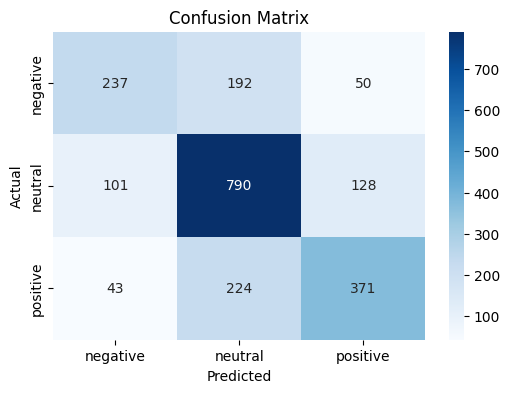

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_cs_test, y_cs_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_logreg_model.classes_, yticklabels=best_logreg_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 2. Random Forest Classifier

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=   4.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   4.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=   4.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   4.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=   4.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   4.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   4.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=

[CV] END bootstrap=True, max_depth=15, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  18.6s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  18.5s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   3.4s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   9.2s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  17.7s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=10; total time=   3.2s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=10; total time=   3.3s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  17.5s
[CV] END bootstrap=True, max_depth=15, min_samples_leaf=1, min_samp

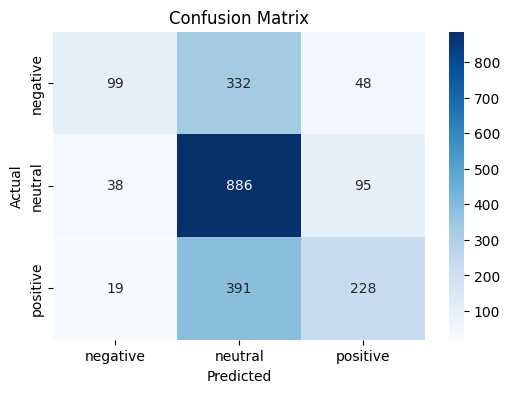

In [33]:
## Define the parameter grid
param_grid_rf = {
    'n_estimators' : [10,50, 100],
    'max_depth' : [None, 5, 10, 15],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'bootstrap' : [True, False]
}

## Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

## Initialise GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model,
                              param_grid=param_grid_rf,
                              cv=5,            # 5 fold cross-validation
                              n_jobs=-1,       # Use all cores
                              verbose=2,
                              scoring='accuracy')

grid_search_rf.fit(X_cs_train, y_cs_train) #RF only
best_rf_model = grid_search_rf.best_estimator_
print("Best parameters:", grid_search_rf.best_params_)
print("step 4: Model Creation and Fitting, is done")

## Use Random Forest to predict the sentiment labels
y_cs_pred_rf = best_rf_model.predict(X_cs_test)
print("step 5: Model Prediction, is done")

## Evaluate the model
# RF
accuracy = accuracy_score(y_cs_test, y_cs_pred_rf)
classification_report2 = classification_report(y_cs_test,y_cs_pred_rf)
print("step 6: Model Evaluation, is done")

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report2}')

# Confusion Matrix
cm = confusion_matrix(y_cs_test, y_cs_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_rf_model.classes_, yticklabels=best_rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. MultinomialNB
- NOTE: only TF-IDF is used here.

step 1: Assigning X and Y, is done
step 2: Train Test Split is done
step 3: Convert Feature names to string, is done
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .........................alpha=0.01, fit_prior=True; total time=   2.5s
[CV] END .........................alpha=0.01, fit_prior=True; total time=   2.5s
[CV] END .........................alpha=0.1, fit_prior=False; total time=   2.5s
[CV] END ........................alpha=0.01, fit_prior=False; total time=   2.4s
[CV] END .........................alpha=0.01, fit_prior=True; total time=   2.6s
[CV] END ........................alpha=0.01, fit_prior=False; total time=   2.6s
[CV] END ........................alpha=0.01, fit_prior=False; total time=   2.6s
[CV] END .........................alpha=0.01, fit_prior=True; total time=   2.6s
[CV] END ........................alpha=0.01, fit_prior=False; total time=   2.7s
[CV] END .........................alpha=0.1, fit_prior=False; total time=   2.5s
[CV] END ....

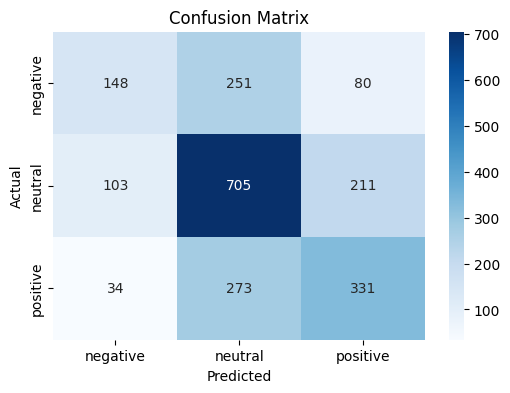

In [36]:
#X_cs = df_combined     # NOT POSSIBLE DUE TO NEGATIVE WEIGHTS
X_cs = tfidf_df_train
y_cs = cs_train['sentiment']

print("step 1: Assigning X and Y, is done")
X_cs_train, X_cs_test, y_cs_train, y_cs_test = train_test_split(X_cs,y_cs,test_size=0.2,
                                                    random_state=42)

print("step 2: Train Test Split is done")
#Convert feature names to strings
X_cs_train.columns = X_cs_train.columns.astype(str)
X_cs_test.columns = X_cs_test.columns.astype(str)
print("step 3: Convert Feature names to string, is done")

from sklearn.naive_bayes import MultinomialNB

## Define the parameter grid
param_grid_nb = {
    'alpha' : [0.01, 0.1, 1, 10],
    'fit_prior' : [True, False]
}

## Initialise the Multinomial Naive Bayes Classifier
nb_model = MultinomialNB()

## Initialise GridSearchCV
grid_search_nb = GridSearchCV(estimator=nb_model,
                              param_grid=param_grid_nb,
                              cv=5,            # 5 fold cross-validation
                              n_jobs=-1,       # Use all cores
                              verbose=2,
                              scoring='accuracy')

# Fit the model
grid_search_nb.fit(X_cs_train, y_cs_train)

# Best model and evaluation
best_nb_model = grid_search_nb.best_estimator_
print("Best parameters:", grid_search_nb.best_params_)
print("Model Creation and Fitting, is done")

## Use Multinomial Naive Bayes to predict the sentiment labels
y_cs_pred_nb = best_nb_model.predict(X_cs_test)
print("Model Prediction, is done")

## Evaluate the model
accuracy = accuracy_score(y_cs_test, y_cs_pred_nb)
classification_report4 = classification_report(y_cs_test,y_cs_pred_nb)
print("Model Evaluation, is done")

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report4}')

# Confusion Matrix
cm = confusion_matrix(y_cs_test, y_cs_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_nb_model.classes_, yticklabels=best_nb_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Based on the 3 different approaches used, it seems that Logistic Regression yields the highest accuracy on the validation set. This was done after finding out that the best hyperparameters are {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}. Now, the model will be tested on the test set.

Side Note: DO NOT compare test accuracy of models to select the best model as this will lead to overfitting of test data

# Testing the best model found of the 3 models tested
- Logistic Regression

Best Hyperparameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
cs_train = pd.read_csv('crowdsourced_train.csv', sep='\t')
#cs_train.head(5)

## Check that the values for the 'sentiment' column are either 'positive',
## 'neutral' or 'negative'
#cs_train['sentiment'].unique()

## Make the 'sentiment' column values universal
## Remove trailing and leading whitespaces in each cell
cs_train['sentiment'] = cs_train['sentiment'].str.strip()

## Convert all values to lowercase
cs_train['sentiment'] = cs_train['sentiment'].str.lower()
#cs_train['sentiment'].unique()

## Replace the values individually
cs_train['sentiment'] = cs_train['sentiment'].replace({
  'neutral?' : 'neutral',
  'nuetral' : 'neutral',
  'netural' : 'neutral',
  '_x0008_neutral' : 'neutral',
  'netutral' : 'neutral',
  'neural' : 'neutral',
  'neutrall' : 'neutral',
  'neugral' : 'neutral',
  'neutrla' : 'neutral',
  'nutral' : 'neutral',
  'neutal' : 'neutral',
  'neutra l' : 'neutral',

  'nedative' : 'negative',
  'negtaive' : 'negative',
  'negayive' : 'negative',

  'postive' : 'positive',
  'positie' : 'positive',
  'npositive' : 'positive',
  'postitive' : 'positive',
  'positve' : 'positive'
})

cs_train['sentiment'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [27]:
X_cs = df_combined
#X_cs = tfidf_df_train
y_cs = cs_train['sentiment']

print("step 1: Assigning X and Y, is done")
X_cs_train, X_cs_test, y_cs_train, y_cs_test = train_test_split(X_cs,y_cs,test_size=0.2,
                                                    random_state=42)

print("step 2: Train Test Split is done")
#Convert feature names to strings
X_cs_train.columns = X_cs_train.columns.astype(str)
X_cs_test.columns = X_cs_test.columns.astype(str)
print("step 3: Convert Feature names to string, is done")

step 1: Assigning X and Y, is done
step 2: Train Test Split is done
step 3: Convert Feature names to string, is done


In [33]:
# Create the Logistic Regression model with the best hyperparameters
best_logreg_model = LogisticRegression(
    C=0.1,
    penalty='l2',
    class_weight=None,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Fit the model on the training data
best_logreg_model.fit(X_cs_train, y_cs_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='liblinear')

In [30]:
#X_test_set = combined_features_test
X_test_set = df_combined_test
y_test_set = test_set['sentiment']

X_test_set.columns = X_test_set.columns.astype(str)

In [31]:
non_numeric_columns = X_test_set.select_dtypes(include=['object']).columns
print(non_numeric_columns)

Index([], dtype='object')




Accuracy: 0.6649167270094135
Classification report:
              precision    recall  f1-score   support

    negative       0.61      0.61      0.61      1077
     neutral       0.64      0.78      0.70      2597
    positive       0.77      0.54      0.64      1850

    accuracy                           0.66      5524
   macro avg       0.67      0.64      0.65      5524
weighted avg       0.68      0.66      0.66      5524



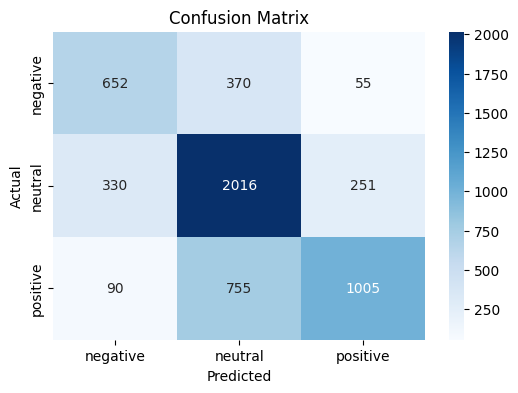

In [34]:
# Make predictions on the test data
y_cs_pred_of_test_set = best_logreg_model.predict(X_test_set)

# Evaluate the model
accuracy = accuracy_score(y_test_set, y_cs_pred_of_test_set)
classification_report6 = classification_report(y_test_set,y_cs_pred_of_test_set)

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report6}')

# Confusion Matrix
cm = confusion_matrix(y_test_set, y_cs_pred_of_test_set)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_logreg_model.classes_, yticklabels=best_logreg_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Final Accuracy on test set: 66.492 % (5sf)

# Repeating above methodology for the gold set
- Checks if labelling affects which model is chosen AKA validation accuracy
- Checks how much labelling affects test accuracy


In [ ]:
#g_train = pd.read_csv('gold_train.csv', sep='\t')
#g_train.head(5)

In [ ]:
#g_train['sentiment'].unique()

In [ ]:
#test_set = pd.read_csv('test.csv', sep='\t')
#test_set.head(5)

In [ ]:
#test_set['sentiment'].unique()

In [ ]:
# Currently have:
# 1) df_combined
# 2) df_combined_test

# Need to train the g_train set on the three different models
# Find the best model of the three with relevant hyperparameters
# Test that best model to get test accuracy

# Training Models on Gold Set


# 1. Logistic Regression


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
X_g = df_combined
#X_g = tfidf_df_train
y_g = g_train['sentiment']

print("step 1: Assigning X and Y, is done")
X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(X_g,y_g,test_size=0.2,
                                                    random_state=42)

print("step 2: Train Test Split is done")
#Convert feature names to strings
X_g_train.columns = X_g_train.columns.astype(str)
X_g_test.columns = X_g_test.columns.astype(str)
print("step 3: Convert Feature names to string, is done")


step 1: Assigning X and Y, is done
step 2: Train Test Split is done
step 3: Convert Feature names to string, is done


In [22]:
non_numeric_columns = X_g_train.select_dtypes(include=['object']).columns
print(non_numeric_columns)

Index([], dtype='object')


In [22]:
# Initialise and train a logistic regression model for multiclass classification
logreg_model = LogisticRegression(max_iter=1000, solver='liblinear') # 'liblinear' supports L1 penalty

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'class_weight' : [None, 'balanced'],
    'solver' : ['liblinear']
}

# Perform grid search
grid_search = GridSearchCV(logreg_model, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_g_train, y_g_train)

# Best model and parameters
best_logreg_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("step 4: Model creation and fitting is done")

## Make predictions on the testing data
y_g_pred = best_logreg_model.predict(X_g_test)
print("step 5: Model prediction on Validation set, is done")

## Evaluate the model
accuracy = accuracy_score(y_g_test, y_g_pred)
classification_report1 = classification_report(y_g_test,y_g_pred)
print("step 6: Model Evaluation, is done")

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report1}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.6943793911007026
step 4: Model creation and fitting is done
step 5: Model prediction on Validation set, is done
step 6: Model Evaluation, is done


Accuracy: 0.6816479400749064
Classification report:
              precision    recall  f1-score   support

    negative       0.59      0.44      0.51       322
     neutral       0.67      0.78      0.72      1053
    positive       0.73      0.65      0.68       761

    accuracy                           0.68      2136
   macro avg       0.67      0.62      0.64      2136
weighted avg       0.68      0.68      0.68      2136



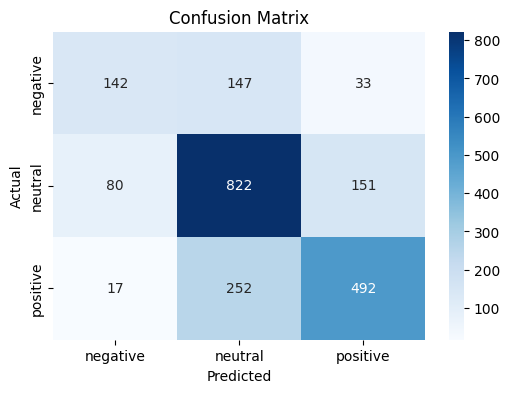

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_g_test, y_g_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_logreg_model.classes_, yticklabels=best_logreg_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# 2. Random Forest

In [23]:
## Define the parameter grid
param_grid_rf = {
    'n_estimators' : [10,50, 100],
    'max_depth' : [None, 5, 10, 15],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'bootstrap' : [True, False]
}

## Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

## Initialise GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model,
                              param_grid=param_grid_rf,
                              cv=5,            # 5 fold cross-validation
                              n_jobs=-1,       # Use all cores
                              verbose=2,
                              scoring='accuracy')

grid_search_rf.fit(X_g_train, y_g_train) #RF only
best_rf_model = grid_search_rf.best_estimator_
print("Best parameters:", grid_search_rf.best_params_)
print("step 4: Model Creation and Fitting, is done")

## Use Random Forest to predict the sentiment labels
y_g_pred_rf = best_rf_model.predict(X_g_test)
print("step 5: Model Prediction, is done")

## Evaluate the model
# RF
accuracy = accuracy_score(y_g_test, y_g_pred_rf)
classification_report2 = classification_report(y_g_test,y_g_pred_rf)
print("step 6: Model Evaluation, is done")

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report2}')


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=  36.8s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=  37.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=  37.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=  37.9s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=  38.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=  37.9s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=  38.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=10; total time=

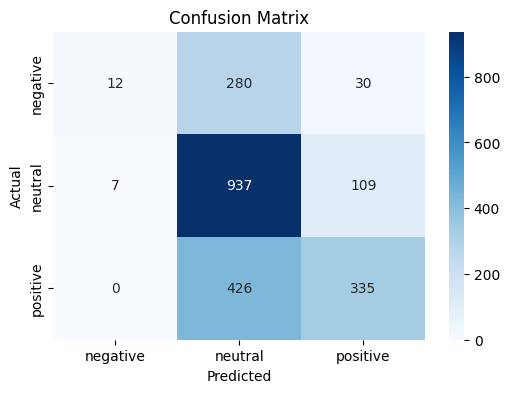

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_g_test, y_g_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_rf_model.classes_, yticklabels=best_rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. Naive Bayes
- tfidf_train is used here as Naive Bayes cannot use nagative weights

In [25]:
#X_cs = df_combined     # NOT POSSIBLE DUE TO NEGATIVE WEIGHTS
X_g = tfidf_df_train
y_g = g_train['sentiment']

print("step 1: Assigning X and Y, is done")
X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(X_g,y_g,test_size=0.2,
                                                    random_state=42)

print("step 2: Train Test Split is done")
#Convert feature names to strings
X_g_train.columns = X_g_train.columns.astype(str)
X_g_test.columns = X_g_test.columns.astype(str)
print("step 3: Convert Feature names to string, is done")

from sklearn.naive_bayes import MultinomialNB

## Define the parameter grid
param_grid_nb = {
    'alpha' : [0.01, 0.1, 1, 10],
    'fit_prior' : [True, False]
}

## Initialise the Multinomial Naive Bayes Classifier
nb_model = MultinomialNB()

## Initialise GridSearchCV
grid_search_nb = GridSearchCV(estimator=nb_model,
                              param_grid=param_grid_nb,
                              cv=5,            # 5 fold cross-validation
                              n_jobs=-1,       # Use all cores
                              verbose=2,
                              scoring='accuracy')

# Fit the model
grid_search_nb.fit(X_g_train, y_g_train)

# Best model and evaluation
best_nb_model = grid_search_nb.best_estimator_
print("Best parameters:", grid_search_nb.best_params_)
print("Model Creation and Fitting, is done")

## Use Multinomial Naive Bayes to predict the sentiment labels
y_g_pred_nb = best_nb_model.predict(X_g_test)
print("Model Prediction, is done")

## Evaluate the model
accuracy = accuracy_score(y_g_test, y_g_pred_nb)
classification_report4 = classification_report(y_g_test,y_g_pred_nb)
print("Model Evaluation, is done")

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report4}')

step 1: Assigning X and Y, is done
step 2: Train Test Split is done
step 3: Convert Feature names to string, is done
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'alpha': 1, 'fit_prior': False}
Model Creation and Fitting, is done
Model Prediction, is done
Model Evaluation, is done


Accuracy: 0.5950374531835206
Classification report:
              precision    recall  f1-score   support

    negative       0.46      0.20      0.28       322
     neutral       0.60      0.69      0.64      1053
    positive       0.61      0.63      0.62       761

    accuracy                           0.60      2136
   macro avg       0.56      0.51      0.51      2136
weighted avg       0.58      0.60      0.58      2136



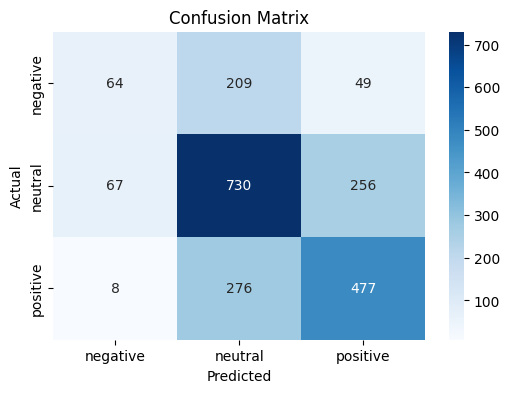

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_g_test, y_g_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_nb_model.classes_, yticklabels=best_nb_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Test the Best Model on the Gold Set
- Logistic Regression Model 

Best Hyperparameters: { 'C': 0.1, 
                        'class_weight': None, 
                        'penalty': 'l2', 
                        'solver': 'liblinear'}

In [25]:
X_g = df_combined
#X_g = tfidf_df_train
y_g = g_train['sentiment']

print("step 1: Assigning X and Y, is done")
X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(X_g,y_g,test_size=0.2,
                                                    random_state=42)

print("step 2: Train Test Split is done")
#Convert feature names to strings
X_g_train.columns = X_g_train.columns.astype(str)
X_g_test.columns = X_g_test.columns.astype(str)
print("step 3: Convert Feature names to string, is done")

step 1: Assigning X and Y, is done
step 2: Train Test Split is done
step 3: Convert Feature names to string, is done


In [26]:
non_numeric_columns = X_g_train.select_dtypes(include=['object']).columns
print(non_numeric_columns)

Index([], dtype='object')


In [27]:
# Create the Logistic Regression model with the best hyperparameters
best_logreg_model = LogisticRegression(
    C=0.1,
    penalty='l2',
    class_weight=None,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Fit the model on the training data
best_logreg_model.fit(X_g_train, y_g_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='liblinear')

In [28]:
#X_test_set = combined_features_test
X_test_set = df_combined_test
y_test_set = test_set['sentiment']

X_test_set.columns = X_test_set.columns.astype(str)



Accuracy: 0.7022085445329471
Classification report:
              precision    recall  f1-score   support

    negative       0.72      0.53      0.61      1077
     neutral       0.67      0.81      0.73      2597
    positive       0.77      0.66      0.71      1850

    accuracy                           0.70      5524
   macro avg       0.72      0.66      0.68      5524
weighted avg       0.71      0.70      0.70      5524



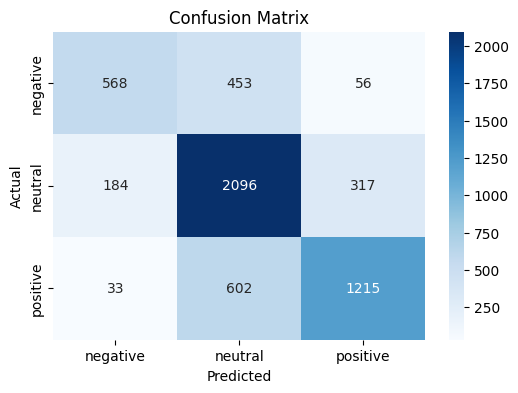

In [29]:
# Make predictions on the test data
y_g_pred_of_test_set = best_logreg_model.predict(X_test_set)

# Evaluate the model
accuracy = accuracy_score(y_test_set, y_g_pred_of_test_set)
classification_report6 = classification_report(y_test_set,y_g_pred_of_test_set)

print("\n")
print(f'Accuracy: {accuracy}')
print(f'Classification report:\n{classification_report6}')

# Confusion Matrix
cm = confusion_matrix(y_test_set, y_g_pred_of_test_set)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_logreg_model.classes_, yticklabels=best_logreg_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Final Test Accuracy Obtained: 70.221 % (5sf)